In [48]:
import sys 
sys.path.append(r"C:\Users\hp\OneDrive - Bina Nusantara\NADZLA ANDRITA INTAN GHAYATRIE's files - ADASYN-Gaussian\hamra-work-adasyn\adasyn_gaussian")

In [49]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


from adasyn_gaussian import AdasynGaussian

evaluate_k = AdasynGaussian.evaluate_k
adasyn_gaussian = AdasynGaussian.generate_synthetic_samples

# Dataset 2: Financial Distress Prediction

source: https://www.kaggle.com/datasets/shebrahimi/financial-distress

In [50]:
df = pd.read_csv(r".\DATASET\Financial Distress.csv")
df

,Company,Time,Financial Distress,x1,x2,x3,x4,x5,x6,x7,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
0,1,1,0.010636,1.2810,0.022934,0.87454,1.21640,0.060940,0.188270,0.52510,...,85.437,27.07,26.102,16.000,16.0,0.2,22,0.060390,30,49
1,1,2,-0.455970,1.2700,0.006454,0.82067,1.00490,-0.014080,0.181040,0.62288,...,107.090,31.31,30.194,17.000,16.0,0.4,22,0.010636,31,50
2,1,3,-0.325390,1.0529,-0.059379,0.92242,0.72926,0.020476,0.044865,0.43292,...,120.870,36.07,35.273,17.000,15.0,-0.2,22,-0.455970,32,51
3,1,4,-0.566570,1.1131,-0.015229,0.85888,0.80974,0.076037,0.091033,0.67546,...,54.806,39.80,38.377,17.167,16.0,5.6,22,-0.325390,33,52
4,2,1,1.357300,1.0623,0.107020,0.81460,0.83593,0.199960,0.047800,0.74200,...,85.437,27.07,26.102,16.000,16.0,0.2,29,1.251000,7,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3667,422,10,0.438020,2.2605,0.202890,0.16037,0.18588,0.175970,0.198400,2.22360,...,100.000,100.00,100.000,17.125,14.5,-7.0,37,0.436380,4,41
3668,422,11,0.482410,1.9615,0.216440,0.20095,0.21642,0.203590,0.189870,1.93820,...,91.500,130.50,132.400,20.000,14.5,-16.0,37,0.438020,5,42
3669,422,12,0.500770,1.7099,0.207970,0.26136,0.21399,0.193670,0.183890,1.68980,...,87.100,175.90,178.100,20.000,14.5,-20.2,37,0.482410,6,43
3670,422,13,0.611030,1.5590,0.185450,0.30728,0.19307,0.172140,0.170680,1.53890,...,92.900,203.20,204.500,22.000,22.0,6.4,37,0.500770,7,44


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 86 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Company             3672 non-null   int64  
 1   Time                3672 non-null   int64  
 2   Financial Distress  3672 non-null   float64
 3   x1                  3672 non-null   float64
 4   x2                  3672 non-null   float64
 5   x3                  3672 non-null   float64
 6   x4                  3672 non-null   float64
 7   x5                  3672 non-null   float64
 8   x6                  3672 non-null   float64
 9   x7                  3672 non-null   float64
 10  x8                  3672 non-null   float64
 11  x9                  3672 non-null   float64
 12  x10                 3672 non-null   float64
 13  x11                 3672 non-null   float64
 14  x12                 3672 non-null   float64
 15  x13                 3672 non-null   float64
 16  x14   

In [52]:
df.describe()

,Company,Time,Financial Distress,x1,x2,x3,x4,x5,x6,x7,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
count,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3.672000e+03,3672.000000,3672.000000,3672.000000,...,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000
mean,182.084423,7.528322,1.040257,1.387820,0.129706,0.615769,8.681599e-01,0.154949,0.106717,0.784031,...,86.839822,91.920506,89.115908,17.780855,15.198708,-2.664305,19.714597,1.100488,13.122277,33.044935
std,117.024636,4.064016,2.652227,1.452926,0.120013,0.177904,5.719519e-01,0.124904,0.210555,1.033606,...,16.706209,64.656504,64.349382,2.040152,2.828648,8.192663,7.508588,2.666733,9.465907,13.714563
min,1.000000,1.000000,-8.631700,0.075170,-0.258080,0.016135,5.350000e-07,-0.269790,-0.627750,0.035160,...,54.806000,24.318000,23.776000,15.250000,12.000000,-20.200000,1.000000,-0.499220,1.000000,2.000000
25%,80.000000,4.000000,0.172275,0.952145,0.048701,0.501888,5.525575e-01,0.070001,-0.027754,0.436003,...,79.951000,39.800000,38.377000,16.000000,13.000000,-7.000000,14.000000,0.189912,6.000000,21.000000
50%,168.000000,7.000000,0.583805,1.183600,0.107530,0.638690,7.752450e-01,0.131830,0.104325,0.641875,...,90.000000,66.120000,59.471000,17.000000,14.500000,0.200000,20.000000,0.594765,11.000000,34.000000
75%,264.250000,11.000000,1.351750,1.506475,0.188685,0.749425,1.039000e+00,0.219570,0.231230,0.896772,...,93.883000,130.500000,132.400000,20.000000,16.000000,2.100000,26.000000,1.355050,17.000000,44.000000
max,422.000000,14.000000,128.400000,51.954000,0.749410,0.967900,6.835600e+00,0.858540,0.929550,38.836000,...,120.870000,227.500000,214.500000,22.000000,22.000000,8.600000,37.000000,128.400000,49.000000,74.000000


In [53]:
# Membuat target biner: Financial Distress < -0.50 → 1 (distressed/minority), >= -0.50 → 0
df['target'] = (df['Financial Distress'] < -0.50).astype(int)
print("Distribusi kelas target:")
print(df['target'].value_counts())
print(f"\nRasio minority: {df['target'].mean():.4f}")

Distribusi kelas target:
target
0    3536
1     136
Name: count, dtype: int64

Rasio minority: 0.0370


In [54]:
# Drop kolom identifier dan kolom Financial Distress (sudah dijadikan target)
df = df.drop(columns=['Company', 'Time', 'Financial Distress'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3672 entries, 0 to 3671
Data columns (total 84 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      3672 non-null   float64
 1   x2      3672 non-null   float64
 2   x3      3672 non-null   float64
 3   x4      3672 non-null   float64
 4   x5      3672 non-null   float64
 5   x6      3672 non-null   float64
 6   x7      3672 non-null   float64
 7   x8      3672 non-null   float64
 8   x9      3672 non-null   float64
 9   x10     3672 non-null   float64
 10  x11     3672 non-null   float64
 11  x12     3672 non-null   float64
 12  x13     3672 non-null   float64
 13  x14     3672 non-null   float64
 14  x15     3672 non-null   float64
 15  x16     3672 non-null   float64
 16  x17     3672 non-null   float64
 17  x18     3672 non-null   float64
 18  x19     3672 non-null   float64
 19  x20     3672 non-null   float64
 20  x21     3672 non-null   float64
 21  x22     3672 non-null   float64
 22  

In [55]:
df.isna().sum().sum()  # Tidak ada missing values

np.int64(0)

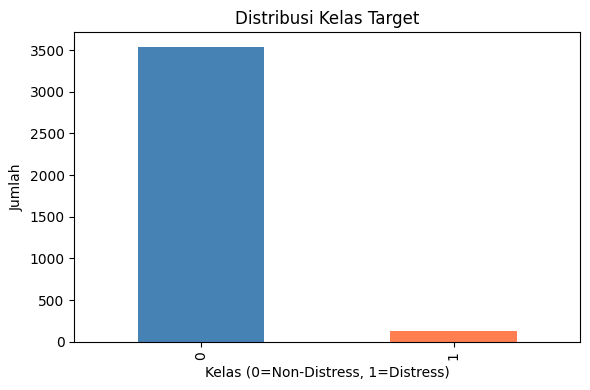

In [56]:
# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Distribusi Kelas Target')
ax.set_xlabel('Kelas (0=Non-Distress, 1=Distress)')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

In [57]:
# Korelasi fitur dengan target
corr_with_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("Top 15 fitur berkorelasi dengan target:")
print(corr_with_target.head(15))

Top 15 fitur berkorelasi dengan target:
x14    0.291381
x49    0.277275
x9     0.269254
x2     0.242083
x10    0.234725
x5     0.229287
x3     0.207098
x13    0.207098
x55    0.192320
x53    0.190683
x37    0.184847
x23    0.181492
x50    0.181490
x36    0.180824
x24    0.171165
Name: target, dtype: float64


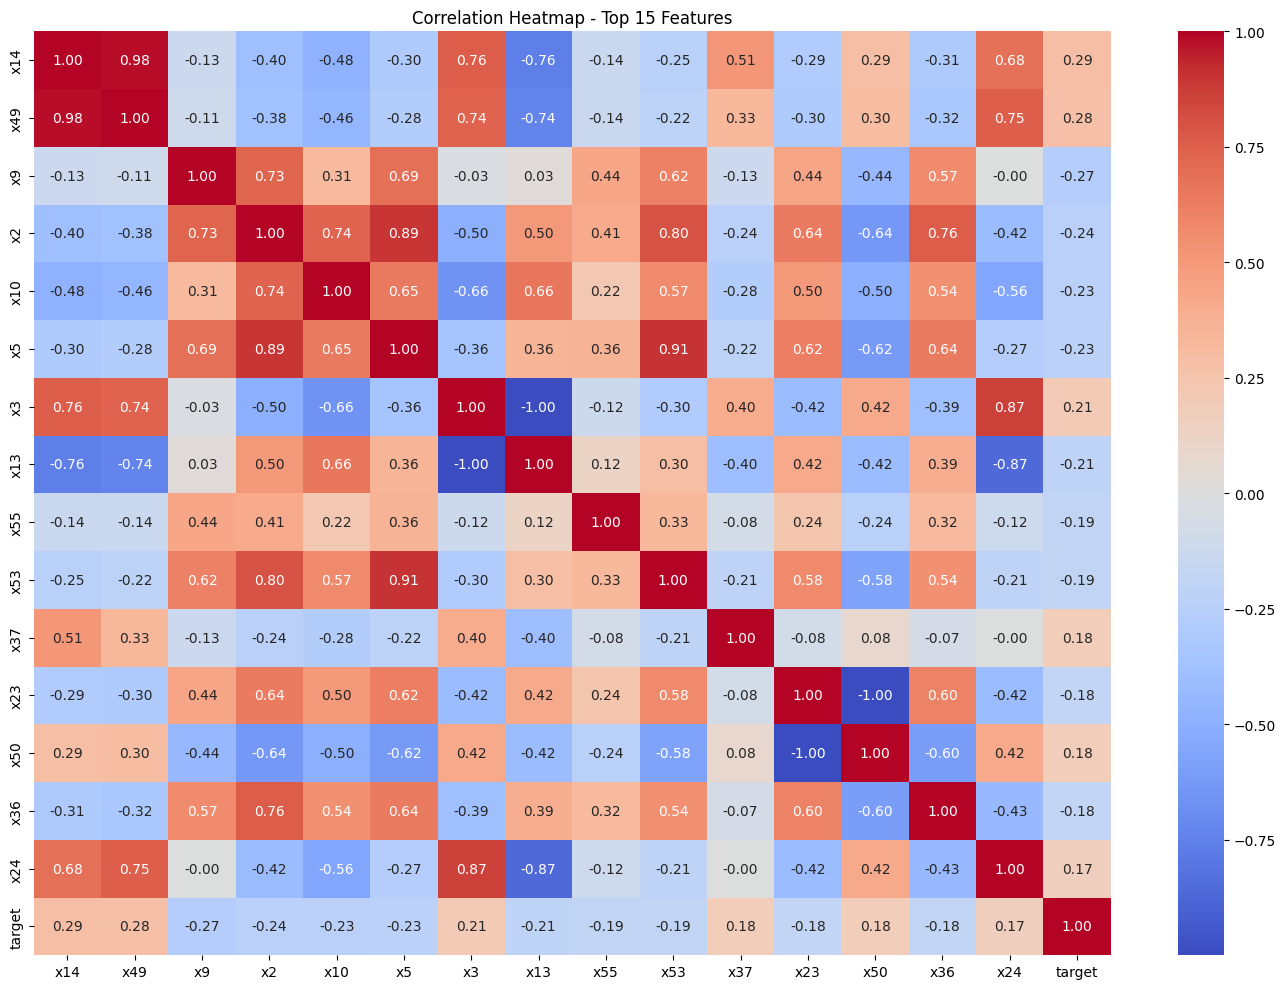

In [58]:
# Heatmap korelasi top 15 fitur + target
top_features = corr_with_target.head(15).index.tolist()
top_features.append('target')
plt.figure(figsize=(14, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Top 15 Features')
plt.tight_layout()
plt.show()

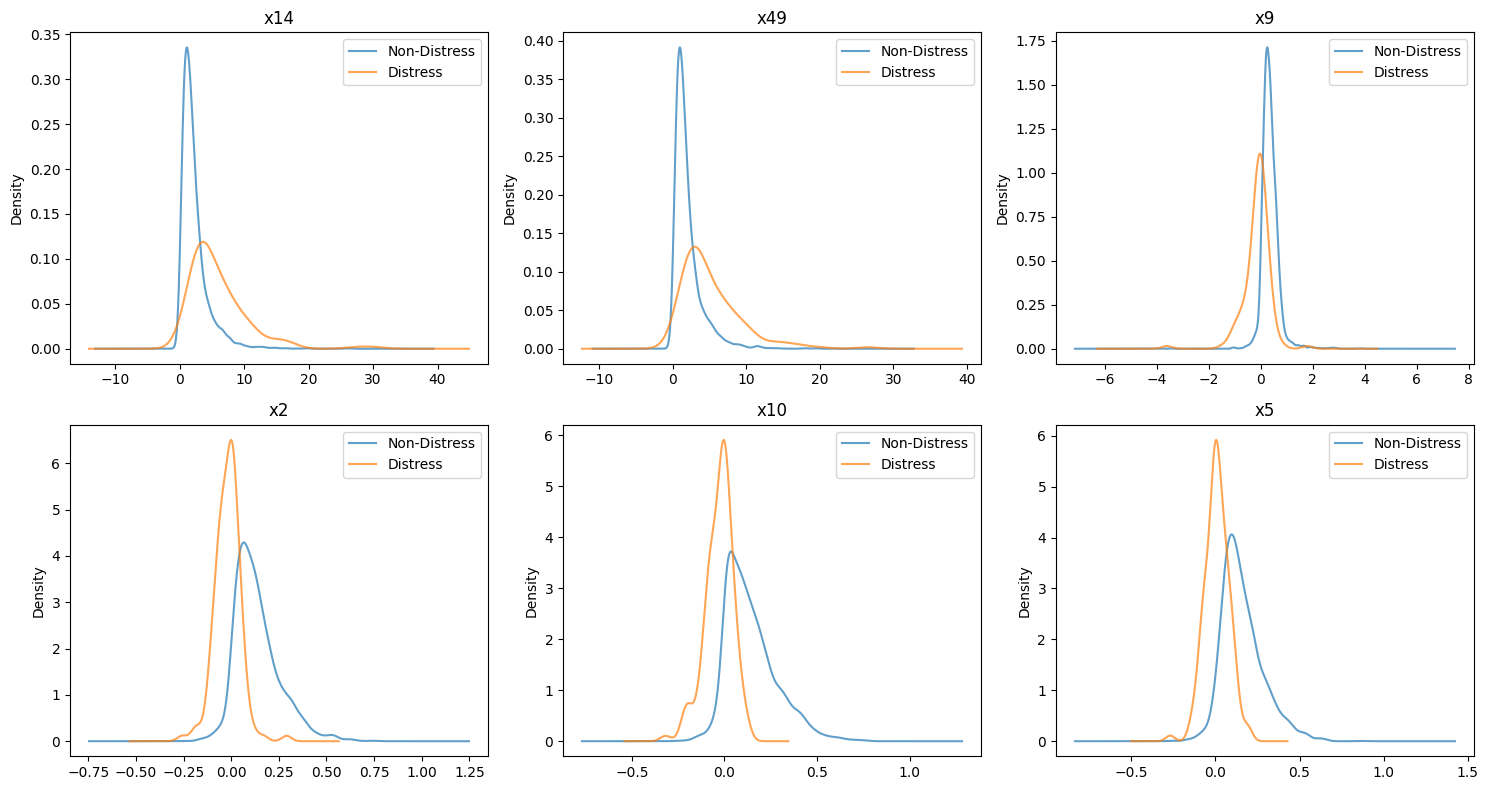

In [59]:
# Distribusi beberapa fitur terhadap target
top_6 = corr_with_target.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(top_6):
    ax = axes.flatten()[i]
    df[df['target']==0][col].plot(kind='kde', ax=ax, label='Non-Distress', alpha=0.7)
    df[df['target']==1][col].plot(kind='kde', ax=ax, label='Distress', alpha=0.7)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

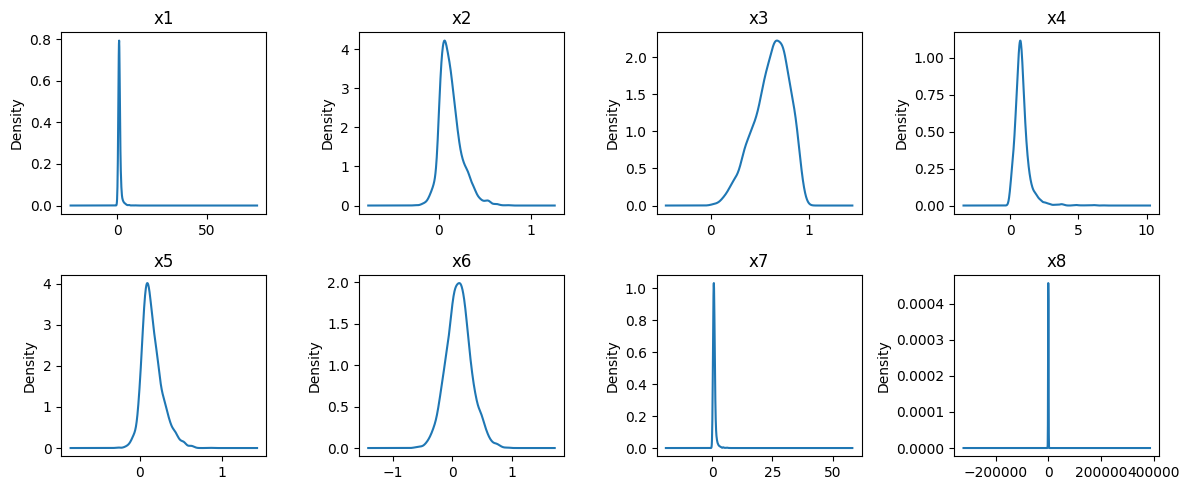

In [60]:
# Distribusi KDE beberapa fitur
sample_features = list(df.columns[:8])  # Ambil 8 fitur pertama
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(sample_features):
    df[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

## Splitting Data

In [61]:
# DEFINE

minority_class = 1
X = df.loc[:, ~df.columns.isin(['target'])].values
y = df['target'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

X shape: (3672, 83), y shape: (3672,)
Class distribution: {0: 3536, 1: 136}


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# ADASYN-Gaussian + Decision Tree

In [63]:
# Define the range of k values to test
k_values = range(2, 10)
beta_values = [0.5, 1.0, 1.5, 2.0]

# Run the evaluation (menggunakan X_train, y_train untuk menghindari data leakage)
results = evaluate_k(X_train, y_train, k_values, beta_values, minority_class=minority_class)

# Find the optimal k
best_k, best_beta, best_f1 = max(results, key=lambda item: item[2])

print(f'Optimal k: {best_k}, Optimal Beta: {best_beta}, F1 score: {best_f1:.4f}')

results

Optimal k: 2, Optimal Beta: 0.5, F1 score: 0.9607


[(2, 0.5, 0.9606579917201283),
 (2, 1.0, 0.9603822631584169),
 (2, 1.5, 0.9603822631584169),
 (2, 2.0, 0.9601068991348237),
 (3, 0.5, 0.9601068991348237),
 (3, 1.0, 0.9592829514999319),
 (3, 1.5, 0.9595572475317445),
 (3, 2.0, 0.9592829514999319),
 (4, 0.5, 0.9595572475317445),
 (4, 1.0, 0.9584621328572123),
 (4, 1.5, 0.9576443339198348),
 (4, 2.0, 0.9579166046246702),
 (5, 0.5, 0.9598318953434233),
 (5, 1.0, 0.958189202970159),
 (5, 1.5, 0.9565584511245971),
 (5, 2.0, 0.9560173775467624),
 (6, 0.5, 0.9606579917201283),
 (6, 1.0, 0.9573723870019091),
 (6, 1.5, 0.9573723870019091),
 (6, 2.0, 0.9549388217248341),
 (7, 0.5, 0.9584621328572123),
 (7, 1.0, 0.9573723870019091),
 (7, 1.5, 0.955477510473103),
 (7, 2.0, 0.9549388217248341),
 (8, 0.5, 0.9568294493433305),
 (8, 1.0, 0.9562877617352326),
 (8, 1.5, 0.9538648697601664),
 (8, 2.0, 0.9538648697601664),
 (9, 0.5, 0.9576443339198348),
 (9, 1.0, 0.9541329379360798),
 (9, 1.5, 0.9533295533994186),
 (9, 2.0, 0.9509335388136068)]

Proses Adasyn-Gaussian

In [64]:
# Menggunakan X_train, y_train untuk menghindari data leakage
X_synthetic, y_synthetic, synthetic_samples = adasyn_gaussian(X_train, y_train, k=best_k, beta=best_beta, minority_class=minority_class)
print(f"Menggunakan k={best_k}, beta={best_beta}")

Menggunakan k=2, beta=0.5


In [65]:
print("Data Sintetis yang Dihasilkan:")
print(synthetic_samples)

Data Sintetis yang Dihasilkan:
[[ 1.20767514e+00  5.57204077e-02  7.89398106e-01 ...  5.59509547e-01
   1.49991406e+01  3.90006324e+01]
 [ 1.20750755e+00  5.51543794e-02  7.88094904e-01 ...  5.56821629e-01
   1.50005354e+01  3.90009801e+01]
 [ 1.21173562e+00  5.71791381e-02  7.86987042e-01 ...  5.58485246e-01
   1.50009944e+01  3.90005241e+01]
 ...
 [ 1.20218049e+00  1.64561438e-07  8.60470162e-01 ... -5.85873253e-02
   7.99887369e+00  3.90009299e+01]
 [ 1.20064597e+00  7.74490407e-04  8.60818150e-01 ... -5.89908364e-02
   8.00193411e+00  3.90015399e+01]
 [ 1.20326883e+00 -3.37703647e-03  8.61993428e-01 ... -6.03730480e-02
   7.99971697e+00  3.90014653e+01]]


In [66]:
print("Jumlah Sampel Sintetis yang Dihasilkan:", len(synthetic_samples))

Jumlah Sampel Sintetis yang Dihasilkan: 1140


In [67]:
print("Jumlah Sampel di Kelas Minoritas Setelah Augmentasi:", sum(y_synthetic == minority_class))

Jumlah Sampel di Kelas Minoritas Setelah Augmentasi: 1235


In [68]:
select_column = df.loc[:, ~df.columns.isin(['target'])]
df_x = pd.DataFrame(X_train, columns=select_column.columns)
df_x

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
0,1.56540,0.190750,0.42479,0.70707,0.280290,0.229490,1.23250,0.269780,0.331620,0.361180,...,82.306,69.66,61.675,17.000,12.0,-6.1,23.0,2.091900,8.0,26.0
1,1.06870,0.148400,0.65650,0.99481,0.190840,0.039145,0.40488,0.149180,0.432030,0.097852,...,107.090,31.31,30.194,17.000,16.0,0.4,18.0,0.477130,10.0,41.0
2,1.09550,0.018428,0.87047,0.88196,0.212260,0.082901,0.81925,0.020894,0.142260,0.080087,...,92.900,203.20,204.500,22.000,22.0,6.4,29.0,1.781600,15.0,31.0
3,0.83234,0.002550,0.67682,0.63343,0.082544,-0.108940,0.42709,0.004026,0.007890,0.011177,...,59.806,44.53,42.822,15.500,14.0,2.1,9.0,0.038133,11.0,30.0
4,2.11960,0.165100,0.49899,1.15440,0.159140,0.472500,0.88901,0.143020,0.329530,0.206400,...,120.870,36.07,35.273,17.000,15.0,-0.2,1.0,0.753560,3.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2565,1.00240,0.246240,0.55839,0.63279,0.214400,0.001267,0.60446,0.389130,0.557600,0.289440,...,95.750,115.25,116.200,18.563,14.5,-11.5,15.0,2.092300,5.0,27.0
2566,0.78910,0.526240,0.34920,0.15675,0.072982,-0.024392,0.48568,3.357300,0.808620,0.531640,...,59.806,44.53,42.822,15.500,14.0,2.1,15.0,5.688400,39.0,53.0
2567,0.58491,0.232370,0.71241,0.69918,0.296390,-0.172390,0.42474,0.332350,0.808010,0.234620,...,87.100,175.90,178.100,20.000,14.5,-20.2,32.0,4.967000,1.0,27.0
2568,1.20230,0.000160,0.86015,0.68442,0.074581,0.144160,0.78480,0.000234,0.001145,-0.008084,...,93.883,82.30,74.497,16.500,13.0,0.6,22.0,-0.059904,8.0,39.0


In [69]:
synthetic_df = pd.DataFrame(synthetic_samples, columns=df_x.columns)
synthetic_df

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
0,1.207675,5.572041e-02,0.789398,0.904738,0.107054,0.152049,0.812063,0.062712,0.272099,0.061856,...,93.883135,82.299400,74.497342,16.498914,12.999753,0.598733,24.999483,0.559510,14.999141,39.000632
1,1.207508,5.515438e-02,0.788095,0.905922,0.105120,0.149185,0.812604,0.062361,0.270138,0.061950,...,93.885844,82.298538,74.497112,16.499836,12.999730,0.600500,24.999530,0.556822,15.000535,39.000980
2,1.211736,5.717914e-02,0.786987,0.906695,0.104580,0.148135,0.810693,0.063528,0.270928,0.062654,...,93.885291,82.298356,74.497684,16.499227,12.998722,0.599827,25.000405,0.558485,15.000994,39.000524
3,1.210084,5.591379e-02,0.788226,0.903767,0.105888,0.151975,0.810460,0.064913,0.273092,0.064796,...,93.884255,82.303011,74.494713,16.499784,13.000204,0.601561,24.998995,0.553795,14.998822,38.999587
4,1.209368,5.670883e-02,0.787775,0.904617,0.103125,0.150856,0.810026,0.061630,0.271214,0.059823,...,93.880869,82.299685,74.496358,16.499866,13.001818,0.598481,25.001643,0.558571,14.999646,38.997229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,1.203698,-1.019046e-03,0.857078,0.685748,0.073963,0.142351,0.784400,-0.002394,-0.000720,-0.008704,...,93.885997,82.301446,74.498992,16.501981,12.999290,0.598210,22.000741,-0.059354,7.999645,39.001478
1136,1.200845,3.837581e-03,0.859909,0.683633,0.074821,0.144727,0.784231,0.002171,0.002444,-0.008040,...,93.883518,82.302726,74.495902,16.499184,12.996387,0.600414,22.002013,-0.060004,7.998794,39.000168
1137,1.202180,1.645614e-07,0.860470,0.681385,0.073884,0.148631,0.785910,0.000705,-0.000688,-0.010518,...,93.885684,82.299682,74.498530,16.499060,13.000633,0.599128,21.998453,-0.058587,7.998874,39.000930
1138,1.200646,7.744904e-04,0.860818,0.683591,0.073352,0.140946,0.785203,0.000814,0.000096,-0.007234,...,93.885242,82.300914,74.497532,16.499401,13.000479,0.599512,22.000415,-0.058991,8.001934,39.001540


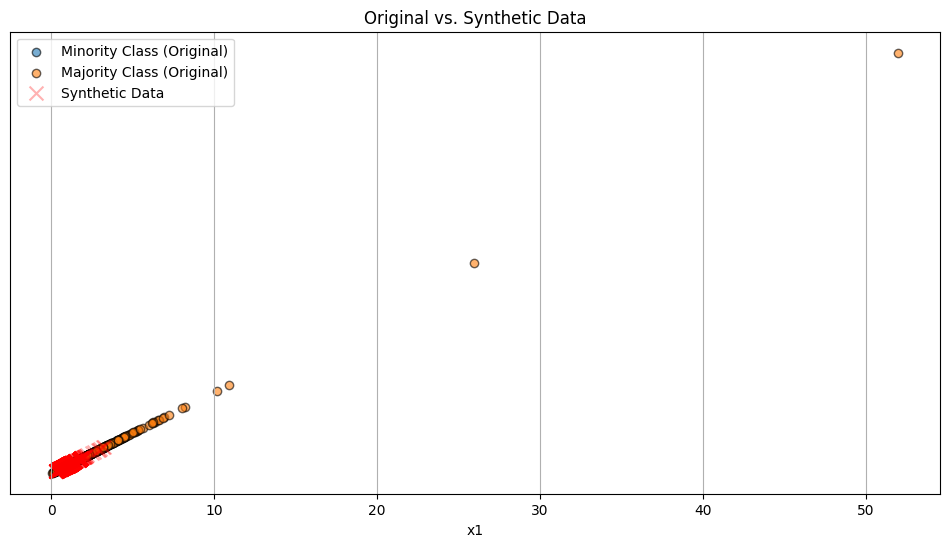

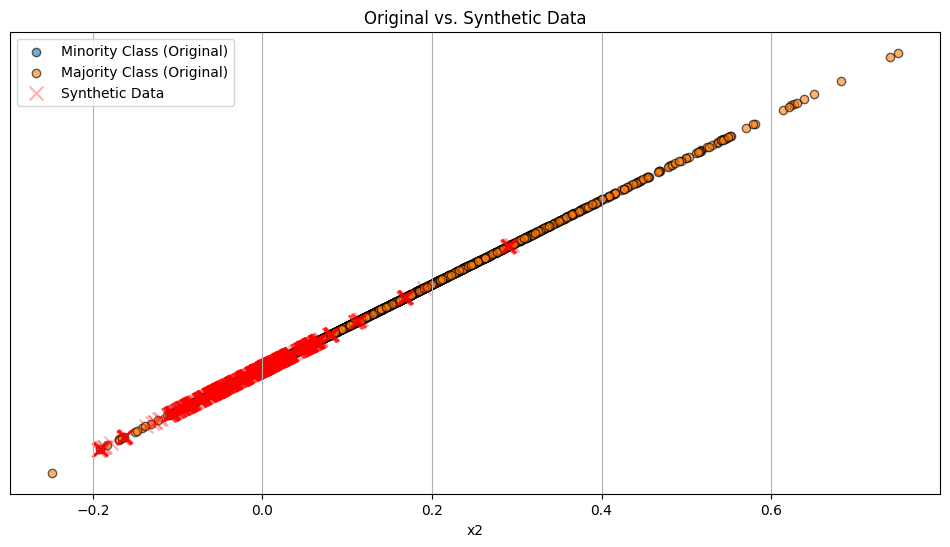

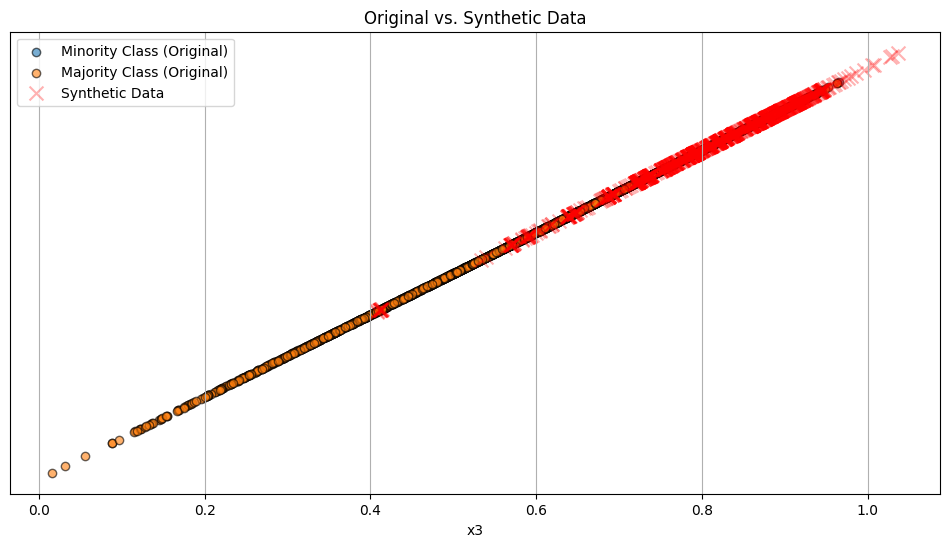

In [70]:
# Visualisasi Data Asli dan Sintetis
feature_names = select_column.columns.tolist()

def plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=0):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices], X_train[y_train == 1, feature_indices], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices], X_train[y_train == 0, feature_indices], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices], synthetic_samples[:, feature_indices], label='Synthetic Data', alpha=0.3, marker='x', color='r', s=100)
    
    plt.xlabel(feature_names[feature_indices])
    plt.yticks([])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

for feature_index in range(3):
    plot_synthetic_vs_original(X_train, y_train, synthetic_samples, feature_indices=feature_index)

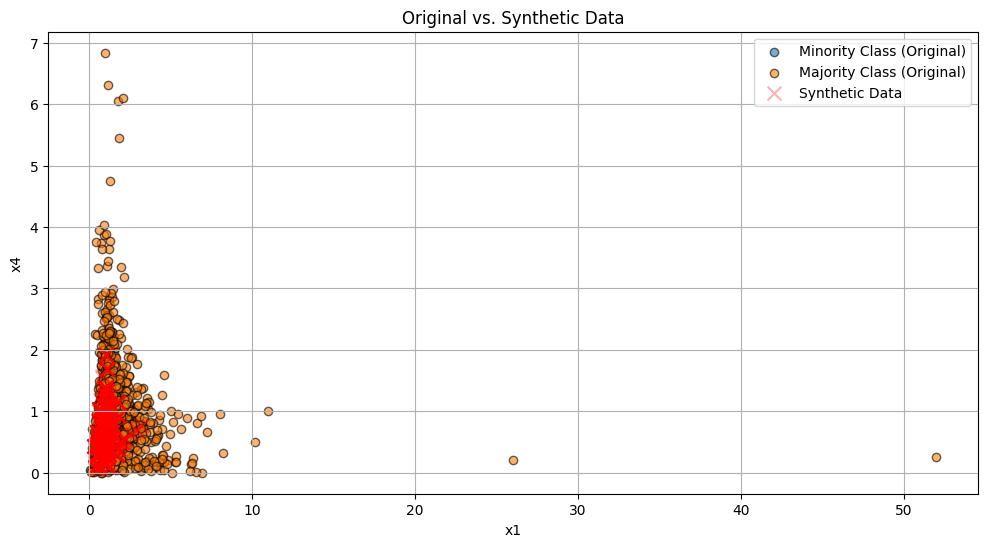

In [71]:
# Visualisasi Data Asli dan Sintetis (2D)
def plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices=[0, 1]):
    plt.figure(figsize=(12, 6))
    
    # Plot data asli
    plt.scatter(X_train[y_train == 1, feature_indices[0]], X_train[y_train== 1, feature_indices[1]], label='Minority Class (Original)', alpha=0.6, edgecolor='k')
    plt.scatter(X_train[y_train == 0, feature_indices[0]], X_train[y_train == 0, feature_indices[1]], label='Majority Class (Original)', alpha=0.6, edgecolor='k')
    
    # Plot data sintetis
    plt.scatter(synthetic_samples[:, feature_indices[0]], synthetic_samples[:, feature_indices[1]], label='Synthetic Data', alpha=0.3, s=100, marker='x', color='r')
    
    plt.xlabel(feature_names[feature_indices[0]])
    plt.ylabel(feature_names[feature_indices[1]])
    plt.title('Original vs. Synthetic Data')
    plt.legend()
    plt.grid(True)
    plt.show()

feature_indices = [0, 3]
plot_synthetic_vs_original_2d(X_train, y_train, synthetic_samples, feature_indices)

In [72]:
display(df_x.head(5), synthetic_df.head(5))

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
0,1.56540,0.190750,0.42479,0.70707,0.280290,0.229490,1.23250,0.269780,0.33162,0.361180,...,82.306,69.66,61.675,17.0,12.0,-6.1,23.0,2.091900,8.0,26.0
1,1.06870,0.148400,0.65650,0.99481,0.190840,0.039145,0.40488,0.149180,0.43203,0.097852,...,107.090,31.31,30.194,17.0,16.0,0.4,18.0,0.477130,10.0,41.0
2,1.09550,0.018428,0.87047,0.88196,0.212260,0.082901,0.81925,0.020894,0.14226,0.080087,...,92.900,203.20,204.500,22.0,22.0,6.4,29.0,1.781600,15.0,31.0
3,0.83234,0.002550,0.67682,0.63343,0.082544,-0.108940,0.42709,0.004026,0.00789,0.011177,...,59.806,44.53,42.822,15.5,14.0,2.1,9.0,0.038133,11.0,30.0
4,2.11960,0.165100,0.49899,1.15440,0.159140,0.472500,0.88901,0.143020,0.32953,0.206400,...,120.870,36.07,35.273,17.0,15.0,-0.2,1.0,0.753560,3.0,37.0


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83
0,1.207675,0.055720,0.789398,0.904738,0.107054,0.152049,0.812063,0.062712,0.272099,0.061856,...,93.883135,82.299400,74.497342,16.498914,12.999753,0.598733,24.999483,0.559510,14.999141,39.000632
1,1.207508,0.055154,0.788095,0.905922,0.105120,0.149185,0.812604,0.062361,0.270138,0.061950,...,93.885844,82.298538,74.497112,16.499836,12.999730,0.600500,24.999530,0.556822,15.000535,39.000980
2,1.211736,0.057179,0.786987,0.906695,0.104580,0.148135,0.810693,0.063528,0.270928,0.062654,...,93.885291,82.298356,74.497684,16.499227,12.998722,0.599827,25.000405,0.558485,15.000994,39.000524
3,1.210084,0.055914,0.788226,0.903767,0.105888,0.151975,0.810460,0.064913,0.273092,0.064796,...,93.884255,82.303011,74.494713,16.499784,13.000204,0.601561,24.998995,0.553795,14.998822,38.999587
4,1.209368,0.056709,0.787775,0.904617,0.103125,0.150856,0.810026,0.061630,0.271214,0.059823,...,93.880869,82.299685,74.496358,16.499866,13.001818,0.598481,25.001643,0.558571,14.999646,38.997229


In [73]:
synthetic_df['target'] = "Synthetic"
synthetic_df

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x75,x76,x77,x78,x79,x80,x81,x82,x83,target
0,1.207675,5.572041e-02,0.789398,0.904738,0.107054,0.152049,0.812063,0.062712,0.272099,0.061856,...,82.299400,74.497342,16.498914,12.999753,0.598733,24.999483,0.559510,14.999141,39.000632,Synthetic
1,1.207508,5.515438e-02,0.788095,0.905922,0.105120,0.149185,0.812604,0.062361,0.270138,0.061950,...,82.298538,74.497112,16.499836,12.999730,0.600500,24.999530,0.556822,15.000535,39.000980,Synthetic
2,1.211736,5.717914e-02,0.786987,0.906695,0.104580,0.148135,0.810693,0.063528,0.270928,0.062654,...,82.298356,74.497684,16.499227,12.998722,0.599827,25.000405,0.558485,15.000994,39.000524,Synthetic
3,1.210084,5.591379e-02,0.788226,0.903767,0.105888,0.151975,0.810460,0.064913,0.273092,0.064796,...,82.303011,74.494713,16.499784,13.000204,0.601561,24.998995,0.553795,14.998822,38.999587,Synthetic
4,1.209368,5.670883e-02,0.787775,0.904617,0.103125,0.150856,0.810026,0.061630,0.271214,0.059823,...,82.299685,74.496358,16.499866,13.001818,0.598481,25.001643,0.558571,14.999646,38.997229,Synthetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1135,1.203698,-1.019046e-03,0.857078,0.685748,0.073963,0.142351,0.784400,-0.002394,-0.000720,-0.008704,...,82.301446,74.498992,16.501981,12.999290,0.598210,22.000741,-0.059354,7.999645,39.001478,Synthetic
1136,1.200845,3.837581e-03,0.859909,0.683633,0.074821,0.144727,0.784231,0.002171,0.002444,-0.008040,...,82.302726,74.495902,16.499184,12.996387,0.600414,22.002013,-0.060004,7.998794,39.000168,Synthetic
1137,1.202180,1.645614e-07,0.860470,0.681385,0.073884,0.148631,0.785910,0.000705,-0.000688,-0.010518,...,82.299682,74.498530,16.499060,13.000633,0.599128,21.998453,-0.058587,7.998874,39.000930,Synthetic
1138,1.200646,7.744904e-04,0.860818,0.683591,0.073352,0.140946,0.785203,0.000814,0.000096,-0.007234,...,82.300914,74.497532,16.499401,13.000479,0.599512,22.000415,-0.058991,8.001934,39.001540,Synthetic


In [74]:
# Data sintetis sudah siap (semua fitur numerik, tidak perlu konversi tipe)
synthetic_df.dtypes

x1        float64
x2        float64
x3        float64
x4        float64
x5        float64
           ...   
x80       float64
x81       float64
x82       float64
x83       float64
target     object
Length: 84, dtype: object

In [75]:
# Menggunakan data augmentasi langsung dari X_synthetic, y_synthetic
X_train_ag = X_synthetic
y_train_ag = y_synthetic

print(f"Training set size: {len(X_train_ag)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution: {pd.Series(y_train_ag).value_counts().to_dict()}")

Training set size: 3710
Test set size: 1102
Training class distribution: {0: 2475, 1: 1235}


In [76]:
# Distribusi kelas setelah augmentasi
print("Distribusi kelas training setelah ADASYN-Gaussian:")
print(pd.Series(y_train_ag).value_counts())

Distribusi kelas training setelah ADASYN-Gaussian:
0    2475
1    1235
Name: count, dtype: int64


In [77]:
# Info training data
print(f"X_train_ag shape: {X_train_ag.shape}")
print(f"y_train_ag shape: {y_train_ag.shape}")
print(f"X_test shape: {X_test.shape}")

X_train_ag shape: (3710, 83)
y_train_ag shape: (3710,)
X_test shape: (1102, 83)


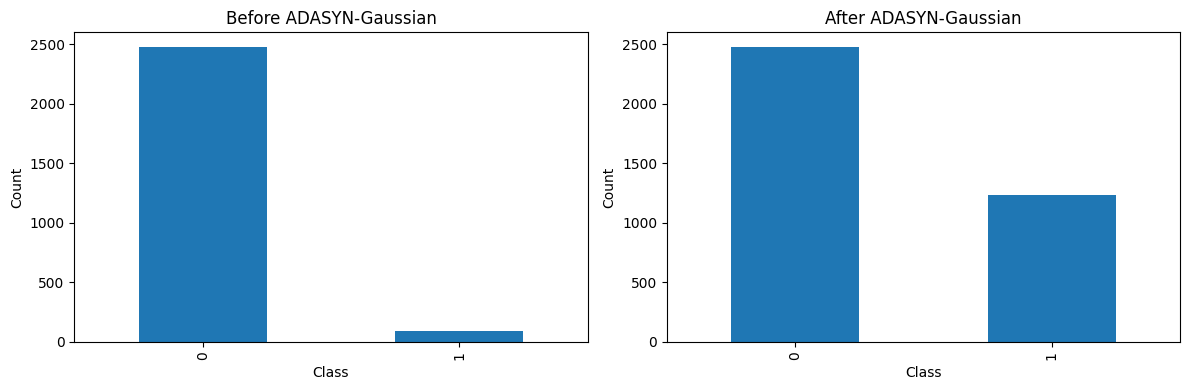

In [78]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], title='Before ADASYN-Gaussian')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
pd.Series(y_train_ag).value_counts().plot(kind='bar', ax=axes[1], title='After ADASYN-Gaussian')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [79]:
# Test set tetap menggunakan X_test, y_test dari train_test_split
X_test_ag = X_test
y_test_ag = y_test
print(f"X_test_ag shape: {X_test_ag.shape}")

X_test_ag shape: (1102, 83)


## Normalization

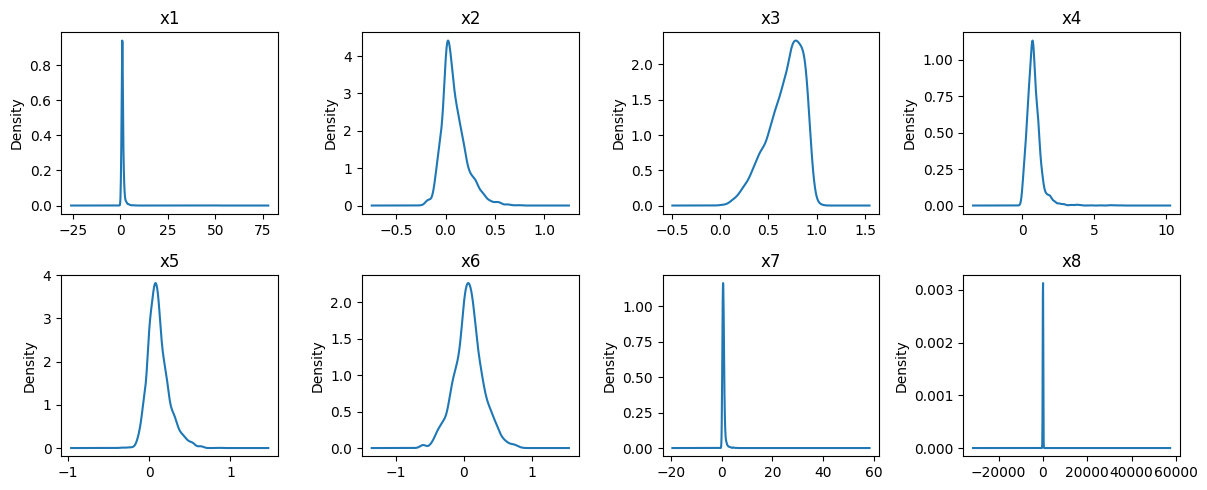

In [80]:
# Visualisasi distribusi fitur sebelum normalisasi (8 fitur pertama)
select_column = df.loc[:, ~df.columns.isin(['target'])]
df_train_viz = pd.DataFrame(X_train_ag, columns=select_column.columns)

sample_cols = list(df_train_viz.columns[:8])
num_rows = 2
num_cols = 4

fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, 5))

for i, column_name in enumerate(sample_cols):
    df_train_viz[column_name].plot(ax=ax.flatten()[i], kind='kde')
    ax.flatten()[i].set_title(column_name)

plt.tight_layout()
plt.show()

In [81]:
# Pastikan y_train_ag adalah integer
y_train_ag = np.array(y_train_ag).astype(int)
y_test_ag = np.array(y_test_ag).astype(int)
print(f"y_train_ag dtype: {y_train_ag.dtype}, y_test_ag dtype: {y_test_ag.dtype}")

y_train_ag dtype: int64, y_test_ag dtype: int64


In [82]:
from sklearn.preprocessing import QuantileTransformer

n_samples = X_train_ag.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_train_ag_scaled = transformer.fit_transform(X_train_ag)
X_test_ag_scaled = transformer.transform(X_test_ag)

print(f"X_train_ag_scaled shape: {X_train_ag_scaled.shape}")
print(f"X_test_ag_scaled shape: {X_test_ag_scaled.shape}")

X_train_ag_scaled shape: (3710, 83)
X_test_ag_scaled shape: (1102, 83)


## Classification

In [83]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report, precision_score, 
                             recall_score, f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)

In [84]:
dt = DecisionTreeClassifier(random_state=42)

In [85]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_train_ag_scaled, y_train_ag)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [86]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9293800539083558


In [87]:
y_pred = grid_search.best_estimator_.predict(X_test_ag_scaled)

In [88]:
print("=== ADASYN-Gaussian + Decision Tree (Financial Distress) ===")
print("Akurasi      :", accuracy_score(y_test_ag, y_pred))
print("Precision    :", precision_score(y_test_ag, y_pred))
print("Recall       :", recall_score(y_test_ag, y_pred))
print("F1 Score     :", f1_score(y_test_ag, y_pred))

=== ADASYN-Gaussian + Decision Tree (Financial Distress) ===
Akurasi      : 0.9319419237749547
Precision    : 0.22580645161290322
Recall       : 0.34146341463414637
F1 Score     : 0.27184466019417475


              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1061
           1       0.23      0.34      0.27        41

    accuracy                           0.93      1102
   macro avg       0.60      0.65      0.62      1102
weighted avg       0.95      0.93      0.94      1102



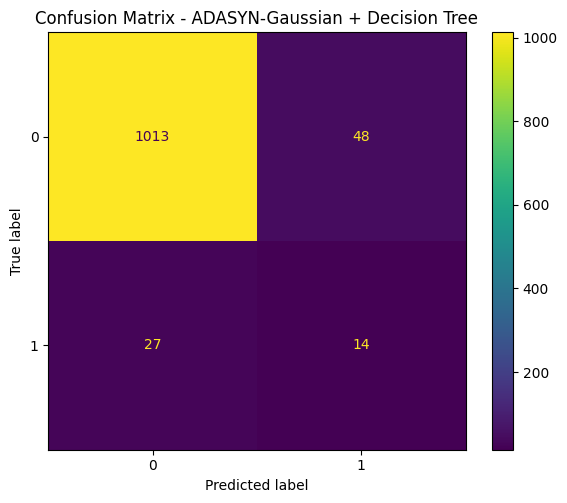

In [89]:
# Classification report
report = classification_report(y_test_ag, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred, ax=ax)
ax.set_title('Confusion Matrix - ADASYN-Gaussian + Decision Tree')
plt.tight_layout()
plt.show()

# ADASYN + Decision Tree

## ROC-AUC Curve - ADASYN-Gaussian + Decision Tree

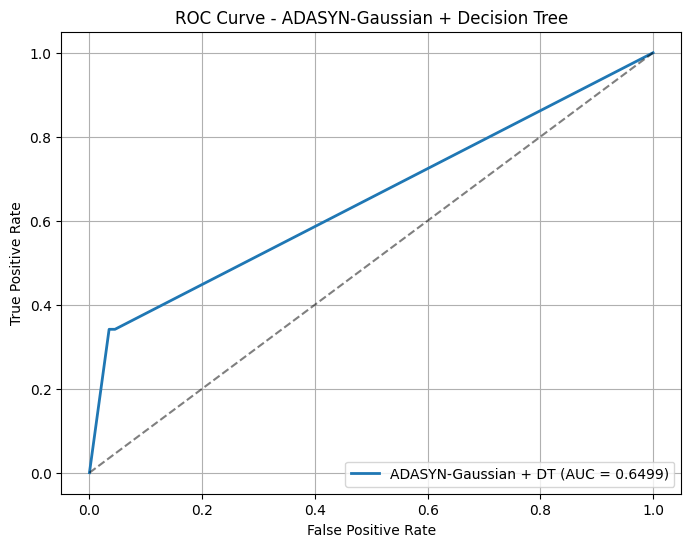

ROC-AUC Score: 0.6499


In [90]:
# ROC-AUC Curve untuk ADASYN-Gaussian + Decision Tree
y_prob_ag = grid_search.best_estimator_.predict_proba(X_test_ag_scaled)[:, 1]
fpr_ag, tpr_ag, _ = roc_curve(y_test_ag, y_prob_ag)
auc_ag = roc_auc_score(y_test_ag, y_prob_ag)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ag, tpr_ag, label=f'ADASYN-Gaussian + DT (AUC = {auc_ag:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - ADASYN-Gaussian + Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {auc_ag:.4f}")

## Perbandingan Multiple Classifiers - ADASYN-Gaussian

In [91]:
# Perbandingan Multiple Classifiers dengan ADASYN-Gaussian
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_ag = []
roc_data_ag = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train_ag_scaled, y_train_ag)
    y_pred_clf = clf.predict(X_test_ag_scaled)
    y_prob_clf = clf.predict_proba(X_test_ag_scaled)[:, 1]
    
    acc = accuracy_score(y_test_ag, y_pred_clf)
    prec = precision_score(y_test_ag, y_pred_clf, zero_division=0)
    rec = recall_score(y_test_ag, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test_ag, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test_ag, y_prob_clf)
    
    results_ag.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test_ag, y_prob_clf)
    roc_data_ag[name] = (fpr_clf, tpr_clf, auc)

results_ag_df = pd.DataFrame(results_ag).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===")
display(results_ag_df)

Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan ADASYN-Gaussian ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9619,0.4839,0.3659,0.4167,0.9153
3,SVM,0.9392,0.3194,0.5610,0.4071,0.9305
4,Logistic Regression,0.9083,0.2500,0.7317,0.3727,0.9134
2,Gradient Boosting,0.9510,0.3243,0.2927,0.3077,0.9172
0,Decision Tree,0.9347,0.2373,0.3415,0.2800,0.6495
5,DT (class_weight=balanced),0.9238,0.1884,0.3171,0.2364,0.6321


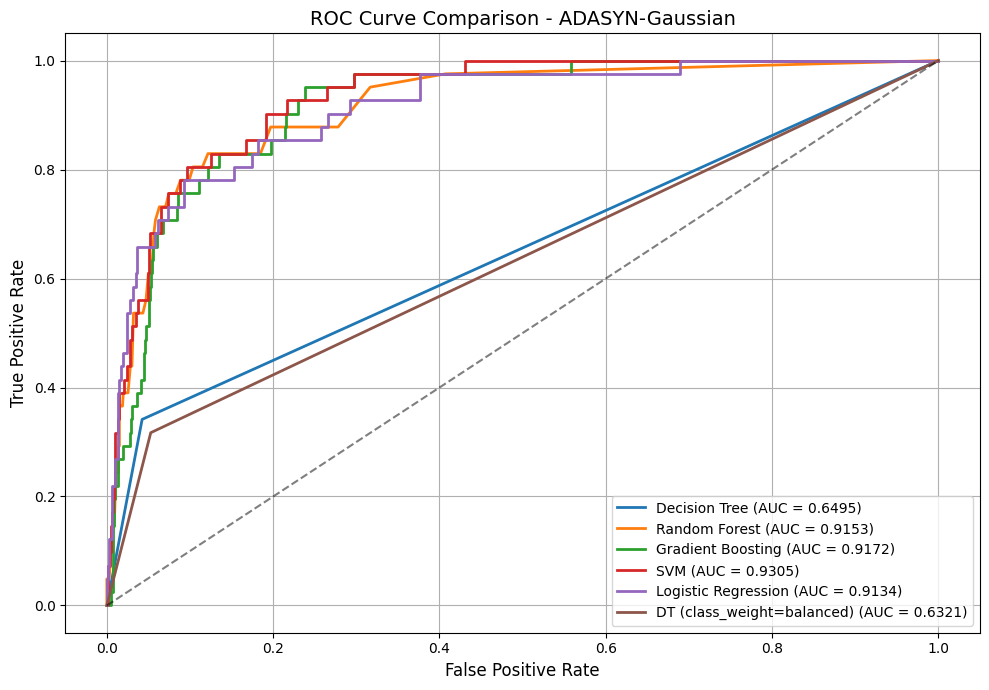

In [92]:
# ROC Curve Comparison - Semua Classifiers (ADASYN-Gaussian)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_ag.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - ADASYN-Gaussian', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

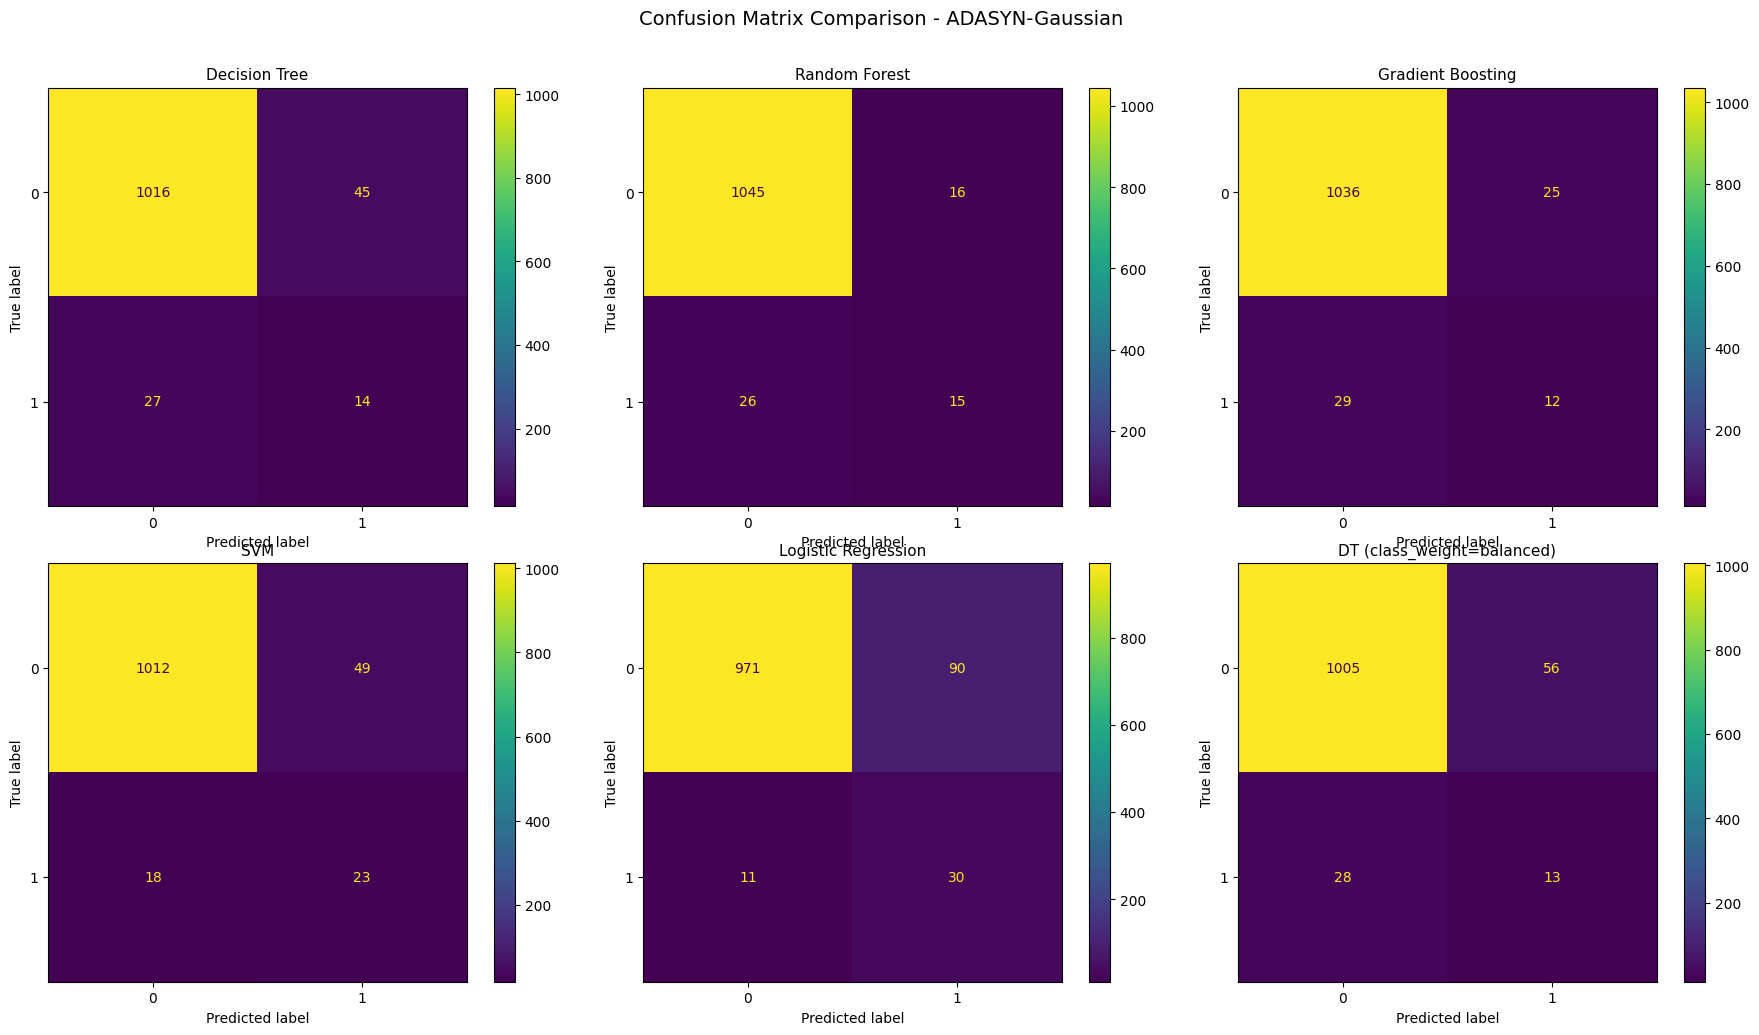

In [93]:
# Confusion Matrix Comparison - Semua Classifiers (ADASYN-Gaussian)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers.items()):
    y_pred_clf = clf.predict(X_test_ag_scaled)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test_ag, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - ADASYN-Gaussian', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ADASYN

In [94]:
# (Sudah diimport dengan try/except di cell sebelumnya)

In [96]:
from imblearn.over_sampling import ADASYN 
from collections import Counter

In [97]:
# Check class distribution before augmentation
print(f'Original class distribution: {Counter(y_train)}')

Original class distribution: Counter({np.int64(0): 2475, np.int64(1): 95})


In [98]:
# Tuning n_neighbors untuk ADASYN
from collections import Counter

best_adasyn_f1 = 0
best_adasyn_n = 2
best_X_res = None
best_y_res = None

for n_neighbors in [2, 3, 5, 7]:
    try:
        adasyn_temp = ADASYN(sampling_strategy='minority', n_neighbors=n_neighbors, random_state=42)
        X_res_temp, y_res_temp = adasyn_temp.fit_resample(X_train, y_train)
        
        # Quick evaluation with Decision Tree
        dt_temp = DecisionTreeClassifier(random_state=42)
        dt_temp.fit(X_res_temp, y_res_temp)
        y_pred_temp = dt_temp.predict(X_test)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        
        print(f"n_neighbors={n_neighbors}: distribution={Counter(y_res_temp)}, F1={f1_temp:.4f}")
        
        if f1_temp > best_adasyn_f1:
            best_adasyn_f1 = f1_temp
            best_adasyn_n = n_neighbors
            best_X_res = X_res_temp
            best_y_res = y_res_temp
    except Exception as e:
        print(f"n_neighbors={n_neighbors}: Error - {e}")

print(f"\nBest n_neighbors: {best_adasyn_n} with F1: {best_adasyn_f1:.4f}")

# Gunakan hasil terbaik
X_resampled = best_X_res
y_resampled = best_y_res

n_neighbors=2: distribution=Counter({np.int64(1): 2495, np.int64(0): 2475}), F1=0.2936
n_neighbors=3: distribution=Counter({np.int64(0): 2475, np.int64(1): 2475}), F1=0.2056
n_neighbors=5: distribution=Counter({np.int64(0): 2475, np.int64(1): 2471}), F1=0.2586
n_neighbors=7: distribution=Counter({np.int64(1): 2489, np.int64(0): 2475}), F1=0.2037

Best n_neighbors: 2 with F1: 0.2936


In [99]:
# Check class distribution after augmentation
print(f'Resampled class distribution (n_neighbors={best_adasyn_n}): {Counter(y_resampled)}')

Resampled class distribution (n_neighbors=2): Counter({np.int64(1): 2495, np.int64(0): 2475})


In [100]:
n_samples = X_resampled.shape[0]
transformer = QuantileTransformer(n_quantiles=min(n_samples, 1000), output_distribution='normal')

X_resampled_scaled = transformer.fit_transform(X_resampled)
X_test_scaled2 = transformer.transform(X_test)


In [101]:
param_grid = {
    'max_depth': [10, 20, 30],        
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4]   
}

# Initialize GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=10, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the model
grid_search.fit(X_resampled_scaled, y_resampled)

Fitting 10 folds for each of 27 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [102]:
# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Score: 0.925754527162978


In [103]:
y_pred = grid_search.best_estimator_.predict(X_test_scaled2)

In [104]:
print("=== Standard ADASYN + Decision Tree (Financial Distress) ===")
print("Akurasi      :", accuracy_score(y_test, y_pred))
print("Precision    :", precision_score(y_test, y_pred))
print("Recall       :", recall_score(y_test, y_pred))
print("F1 Score     :", f1_score(y_test, y_pred))

=== Standard ADASYN + Decision Tree (Financial Distress) ===
Akurasi      : 0.895644283121597
Precision    : 0.19672131147540983
Recall       : 0.5853658536585366
F1 Score     : 0.294478527607362


              precision    recall  f1-score   support

           0       0.98      0.91      0.94      1061
           1       0.20      0.59      0.29        41

    accuracy                           0.90      1102
   macro avg       0.59      0.75      0.62      1102
weighted avg       0.95      0.90      0.92      1102



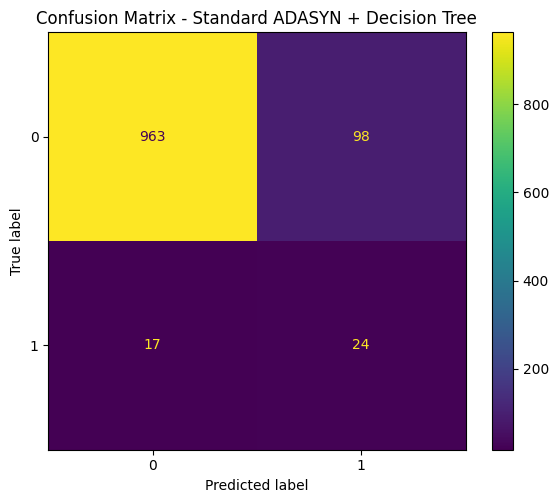

In [105]:
# Classification report
report = classification_report(y_test, y_pred, zero_division=1)
print(report)

# Confusion Matrix
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title('Confusion Matrix - Standard ADASYN + Decision Tree')
plt.tight_layout()
plt.show()

In [106]:
# Perbandingan Multiple Classifiers dengan Standard ADASYN
classifiers_adasyn = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'DT (class_weight=balanced)': DecisionTreeClassifier(class_weight='balanced', random_state=42)
}

results_adasyn = []
roc_data_adasyn = {}

for name, clf in classifiers_adasyn.items():
    print(f"Training {name}...")
    clf.fit(X_resampled_scaled, y_resampled)
    y_pred_clf = clf.predict(X_test_scaled2)
    y_prob_clf = clf.predict_proba(X_test_scaled2)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_clf)
    prec = precision_score(y_test, y_pred_clf, zero_division=0)
    rec = recall_score(y_test, y_pred_clf, zero_division=0)
    f1 = f1_score(y_test, y_pred_clf, zero_division=0)
    auc = roc_auc_score(y_test, y_prob_clf)
    
    results_adasyn.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    })
    
    fpr_clf, tpr_clf, _ = roc_curve(y_test, y_prob_clf)
    roc_data_adasyn[name] = (fpr_clf, tpr_clf, auc)

results_adasyn_df = pd.DataFrame(results_adasyn).sort_values('F1 Score', ascending=False)
print("\n=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===")
display(results_adasyn_df)

Training Decision Tree...


Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training Logistic Regression...
Training DT (class_weight=balanced)...

=== Hasil Perbandingan Classifiers dengan Standard ADASYN ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,Logistic Regression,0.9328,0.2857,0.5366,0.3729,0.8803
2,Gradient Boosting,0.9247,0.2375,0.4634,0.3140,0.8920
1,Random Forest,0.9483,0.3095,0.3171,0.3133,0.9056
5,DT (class_weight=balanced),0.9247,0.2237,0.4146,0.2906,0.6795
0,Decision Tree,0.9283,0.2286,0.3902,0.2883,0.6697
3,SVM,0.9365,0.2264,0.2927,0.2553,0.9063


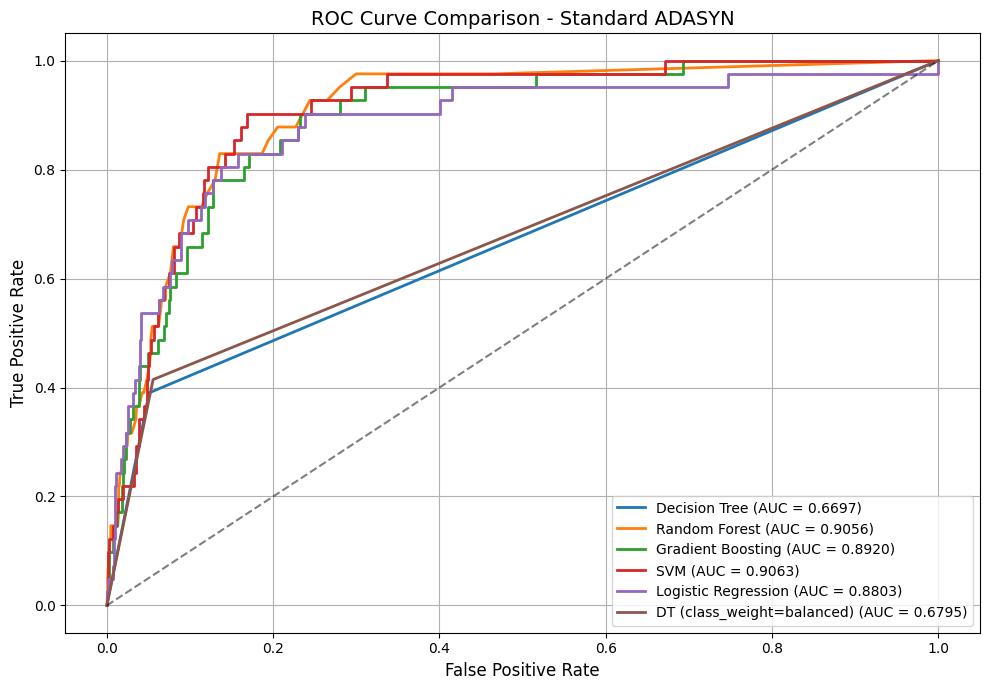

In [107]:
# ROC Curve Comparison - Semua Classifiers (Standard ADASYN)
plt.figure(figsize=(10, 7))
for name, (fpr_clf, tpr_clf, auc_clf) in roc_data_adasyn.items():
    plt.plot(fpr_clf, tpr_clf, label=f'{name} (AUC = {auc_clf:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Standard ADASYN', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

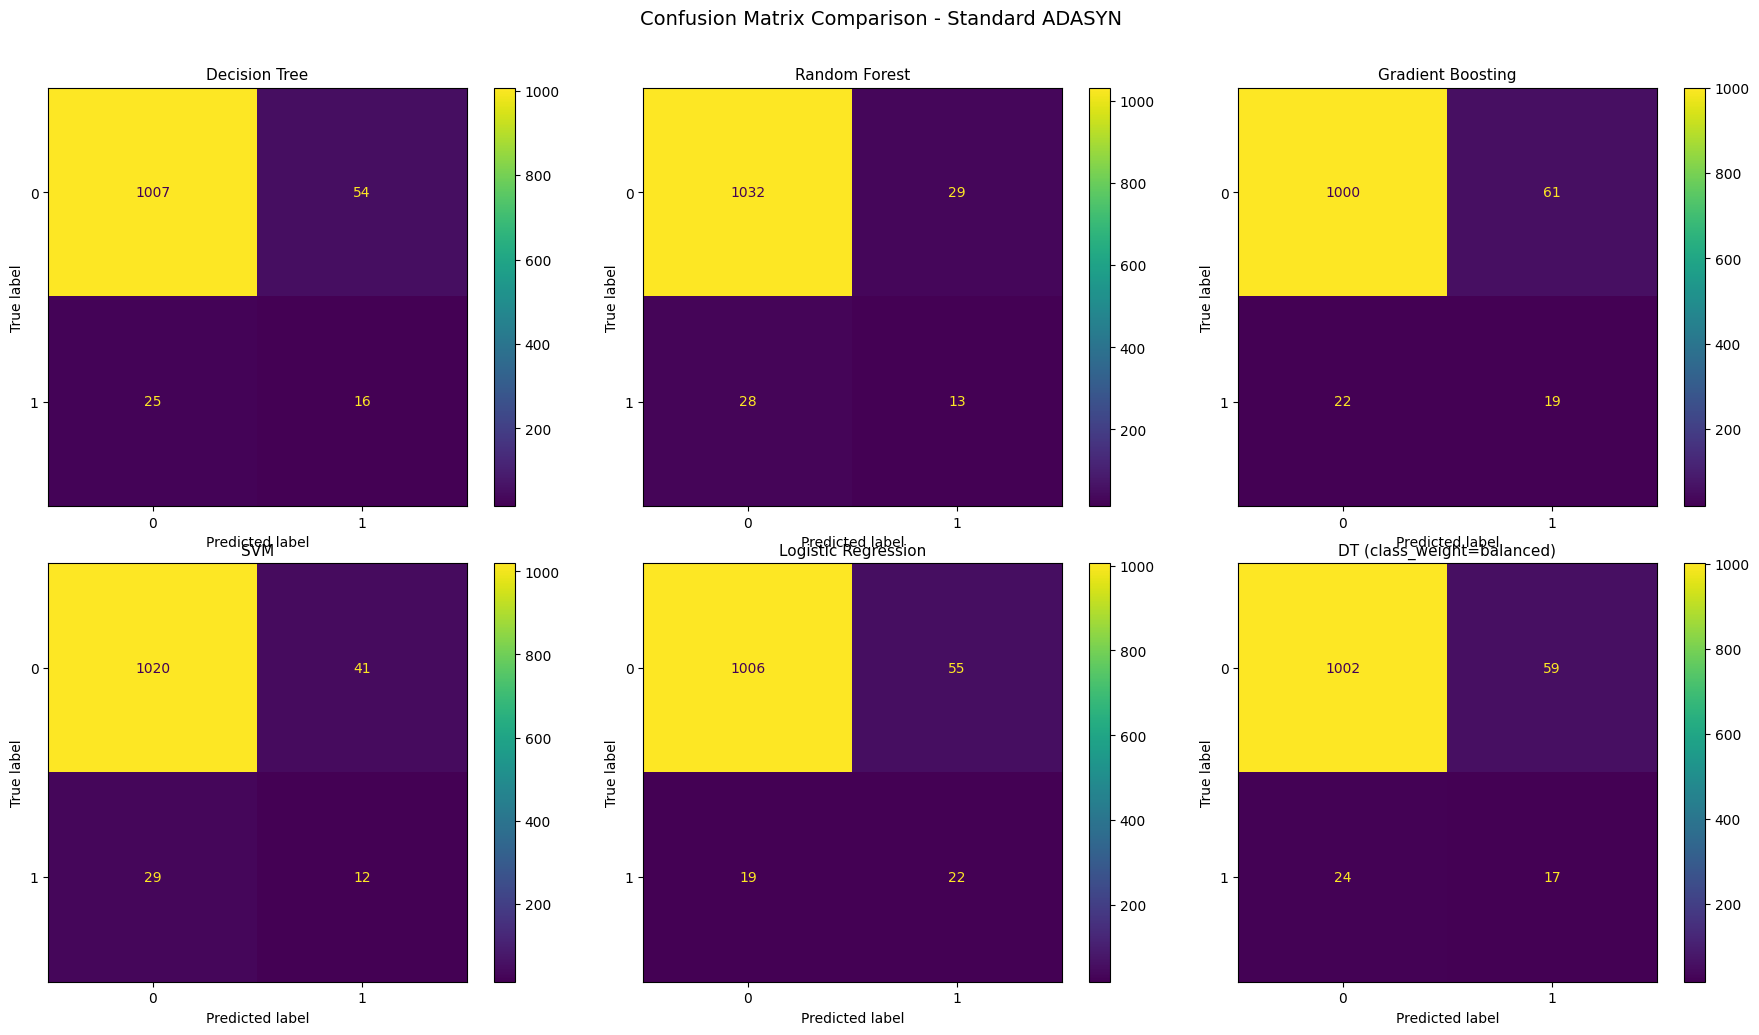

In [108]:
# Confusion Matrix Comparison - Semua Classifiers (Standard ADASYN)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, clf) in enumerate(classifiers_adasyn.items()):
    y_pred_clf = clf.predict(X_test_scaled2)
    ax = axes.flatten()[idx]
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf, ax=ax)
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison - Standard ADASYN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN

In [109]:
# Tabel Perbandingan ADASYN-Gaussian vs Standard ADASYN
results_ag_df['Method'] = 'ADASYN-Gaussian'
results_adasyn_df['Method'] = 'Standard ADASYN'

comparison_df = pd.concat([results_ag_df, results_adasyn_df], ignore_index=True)
comparison_df = comparison_df[['Method', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']]
comparison_df = comparison_df.sort_values(['Model', 'Method'])

print("=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===")
display(comparison_df)

# Highlight best F1 per method
print("\n--- Best Model per Method ---")
for method in ['ADASYN-Gaussian', 'Standard ADASYN']:
    best = comparison_df[comparison_df['Method'] == method].sort_values('F1 Score', ascending=False).iloc[0]
    print(f"{method}: {best['Model']} (F1={best['F1 Score']}, AUC={best['ROC-AUC']})")

=== Perbandingan Akhir: ADASYN-Gaussian vs Standard ADASYN ===


,Method,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,ADASYN-Gaussian,DT (class_weight=balanced),0.9238,0.1884,0.3171,0.2364,0.6321
9,Standard ADASYN,DT (class_weight=balanced),0.9247,0.2237,0.4146,0.2906,0.6795
4,ADASYN-Gaussian,Decision Tree,0.9347,0.2373,0.3415,0.2800,0.6495
10,Standard ADASYN,Decision Tree,0.9283,0.2286,0.3902,0.2883,0.6697
3,ADASYN-Gaussian,Gradient Boosting,0.9510,0.3243,0.2927,0.3077,0.9172
7,Standard ADASYN,Gradient Boosting,0.9247,0.2375,0.4634,0.3140,0.8920
2,ADASYN-Gaussian,Logistic Regression,0.9083,0.2500,0.7317,0.3727,0.9134
6,Standard ADASYN,Logistic Regression,0.9328,0.2857,0.5366,0.3729,0.8803
0,ADASYN-Gaussian,Random Forest,0.9619,0.4839,0.3659,0.4167,0.9153
8,Standard ADASYN,Random Forest,0.9483,0.3095,0.3171,0.3133,0.9056



--- Best Model per Method ---
ADASYN-Gaussian: Random Forest (F1=0.4167, AUC=0.9153)
Standard ADASYN: Logistic Regression (F1=0.3729, AUC=0.8803)


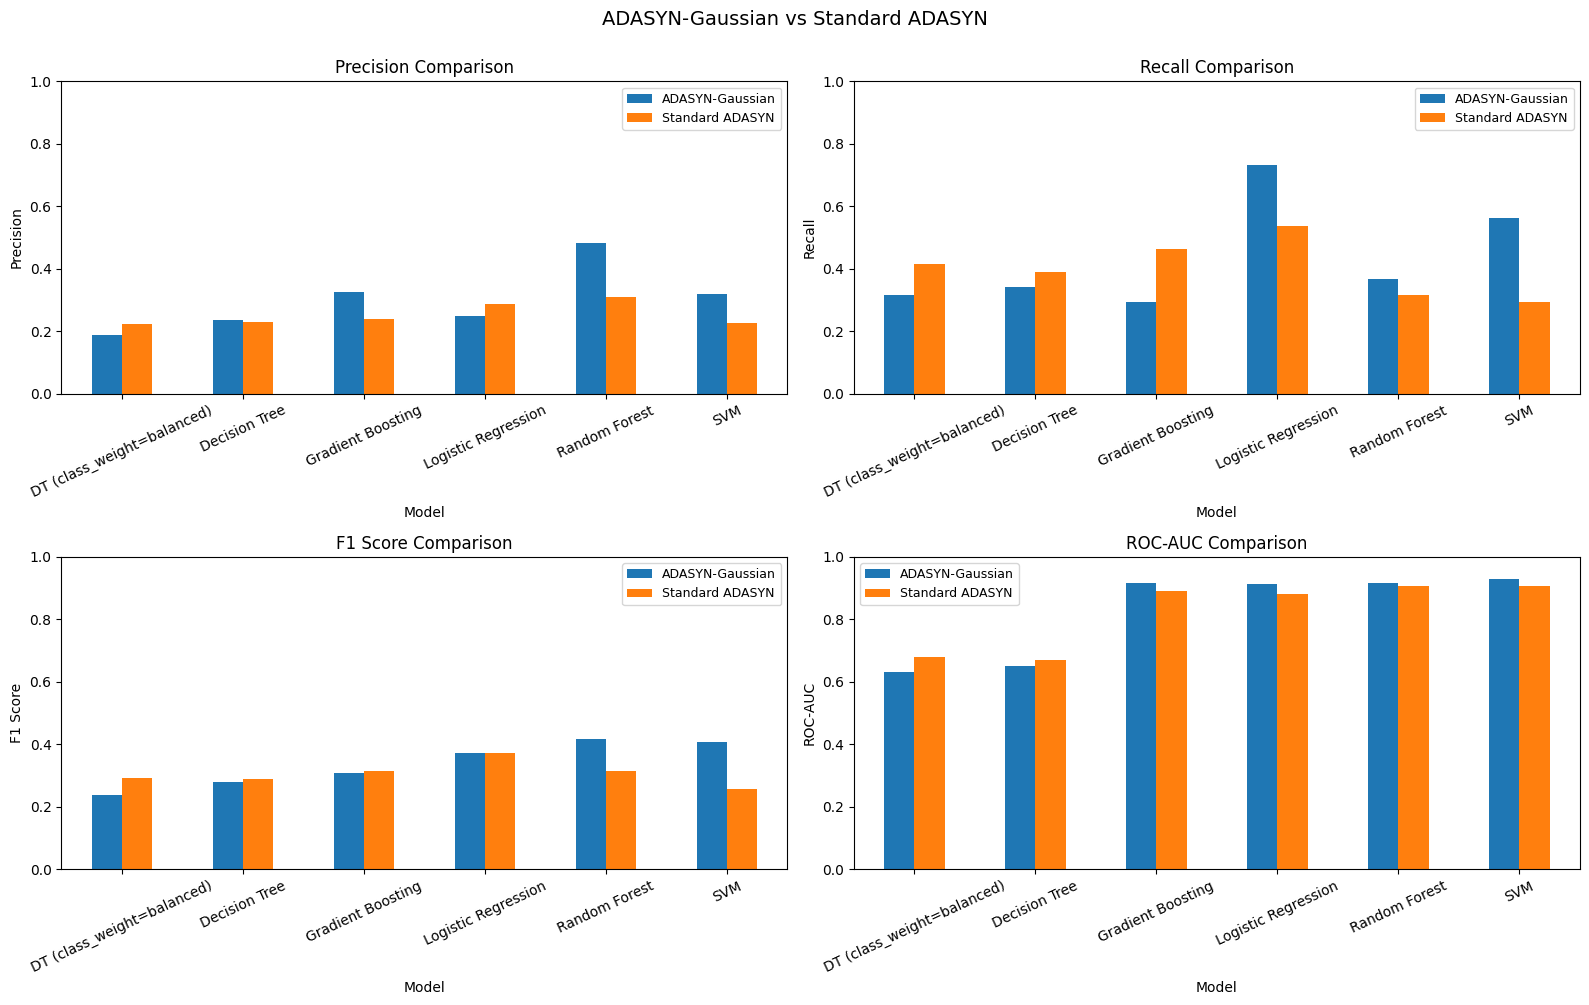

In [111]:
# Visualisasi Bar Chart Perbandingan dengan Precision
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
for i, metric in enumerate(metrics_to_plot):
    ax = axes.flatten()[i]
    pivot = comparison_df.pivot(index='Model', columns='Method', values=metric)
    pivot.plot(kind='bar', ax=ax, rot=25)
    ax.set_title(f'{metric} Comparison', fontsize=12)
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle('ADASYN-Gaussian vs Standard ADASYN', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()